# 실습 4-3 : SVDD (Support Vector Data Description)

#### **<실습 내용>**

1. SVDD 개념 이해
- One-Class Learning 소개
- SVDD 원리

2. SVDD 모델 학습
- 정상 데이터만으로 Boundary 학습

3. 하이퍼 파라미터 (nu) 변화에 따른 영향
- 과적합 / 과소적합 확인

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import OneClassSVM

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 데이터 불러오기

In [2]:
data = pd.read_csv("dataset/day4-3_data.csv")
print("데이터 크기:", data.shape)
print()
print("클래스 분포:")
print(data["Y"].value_counts())
data.head()

데이터 크기: (100, 3)

클래스 분포:
Y
 1    50
-1    50
Name: count, dtype: int64


,0,1,Y
0,1.040235,-1.873163,1
1,-0.287562,3.278405,1
2,1.100316,3.462647,1
3,2.008401,0.555708,1
4,-0.968919,-2.632187,1


---

## 1) SVDD 개념

> **One-Class 모델**: 정상 데이터만 보고 정상 영역을 학습한 뒤, 그 영역을 벗어나면 이상치로 판단하는 기법
>
> **SVDD**: 정상 데이터를 감싸는 가장 작은 원(구) 모양의 경계를 만드는 방법
> - 중심과 반지름을 학습해서 정상 영역을 정의함
> - $C$ 값이 크면 오분류를 덜 허용해서 경계가 더 타이트해짐 (과적합 위험)
>
> sklearn의 `OneClassSVM`이 이 SVDD와 비슷한 방식의 모델임

### 1-1) 데이터 시각화

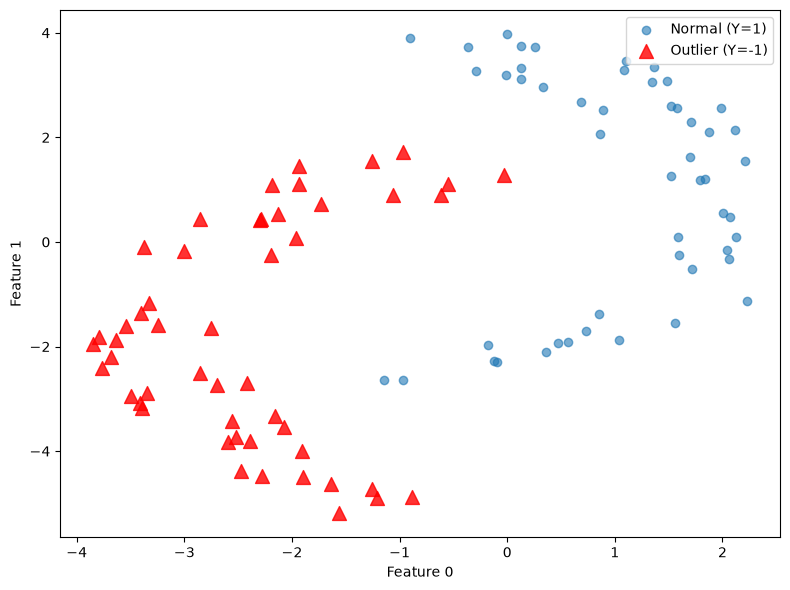

In [3]:
plt.figure(figsize=(8, 6))
normal = data[data["Y"] == 1]  # 정상 데이터만 추출
outlier = data[data["Y"] == -1]  # 이상치 데이터만 추출

plt.scatter(normal["0"], normal["1"], label="Normal (Y=1)", alpha=0.6)  # 정상 데이터 산점도
plt.scatter(outlier["0"], outlier["1"], label="Outlier (Y=-1)", marker="^", s=100, c="red", alpha=0.8)  # 이상치는 빨간 세모로 표시
plt.legend()
plt.xlabel("Feature 0"); plt.ylabel("Feature 1")
plt.tight_layout()
plt.show()

---

## 2) SVDD 모델 학습

> One-Class SVM은 **정상 데이터만으로** 학습함
> - `nu` 파라미터는 이상치 비율의 상한을 설정함 (SVDD의 $C$와 유사한 역할)
> - `kernel="rbf"`를 사용하면 비선형 Boundary를 학습함

### 2-1) 학습/테스트 데이터 분할

In [4]:
X = data[["0", "1"]]
Y = data["Y"]

# 정상 데이터만 추출하여 학습
X_normal = X[Y == 1]
X_outlier = X[Y == -1]

X_train, X_test_normal = train_test_split(X_normal, test_size=0.3, random_state=0)

# 테스트 데이터: 정상 + 이상치
X_test = pd.concat([X_test_normal, X_outlier])
Y_test = pd.Series([1] * len(X_test_normal) + [-1] * len(X_outlier))

print("학습 데이터 (정상만):", X_train.shape)
print("테스트 데이터:", X_test.shape, "(정상:", len(X_test_normal), "이상치:", len(X_outlier),")")

학습 데이터 (정상만): (35, 2)
테스트 데이터: (65, 2) (정상: 15 이상치: 50 )


### 2-2) 모델 학습 및 Boundary 시각화

> `kernel` 옵션 종류
> - `"linear"`: 직선 경계
> - `"poly"`: 다항식 형태의 곡선 경계
> - `"rbf"` (기본값): 가장 유연한 비선형 경계
> - `"sigmoid"`: S자 형태 함수 기반 경계

In [5]:
# One-Class SVM 학습 (nu=0.1, rbf 커널)

# nu : 이상치로 허용할 비율의 상한선
# kernel="rbf" : 곡선 형태로 유연하게 경계를 그림
# gamma="auto" : 경계를 얼마나 세세하게 그릴지 설정 

oc_svm = OneClassSVM(kernel="rbf", gamma="auto", nu=0.1)
oc_svm.fit(X_train)  # 정상 데이터만으로 학습

,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"nu nu: float, default=0.5An upper bound on the fraction of trainingerrors and a lower bound of the fraction of supportvectors. Should be in the interval (0, 1]. By default 0.5will be taken.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1
Name,Type,Value


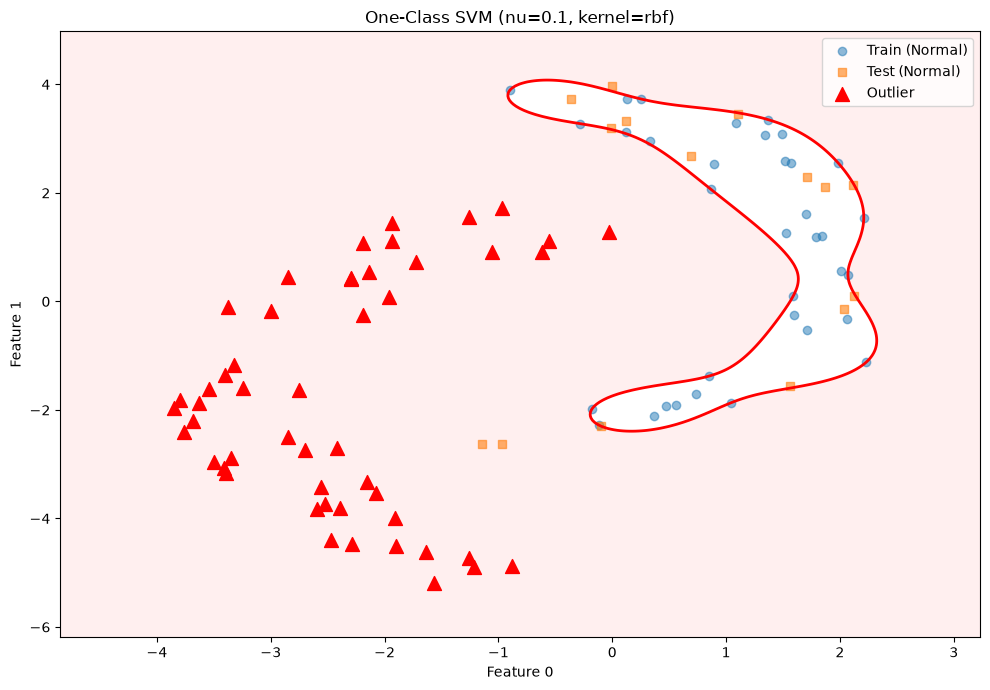

In [6]:
# Decision Boundary 시각화
xx, yy = np.meshgrid(np.linspace(X["0"].min()-1, X["0"].max()+1, 300),  
                     np.linspace(X["1"].min()-1, X["1"].max()+1, 300))
Z = oc_svm.decision_function(pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=["0", "1"])) # 격자의 각 점이 정상 영역에서 얼마나 떨어져있는지 계산
Z = Z.reshape(xx.shape)  # 원래 격자 모양으로 복원

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, levels=[Z.min(), 0], colors=["#ffcccc"], alpha=0.3)  # 이상치로 판단되는 영역을 옅은 빨강으로 채움
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors="red")  # 정상/이상치를 가르는 경계선 그리기
plt.scatter(X_train["0"], X_train["1"], label="Train (Normal)", alpha=0.5)  # 학습에 사용한 정상 데이터
plt.scatter(X_test_normal["0"], X_test_normal["1"], label="Test (Normal)", marker="s", alpha=0.6)  # 테스트용 정상 데이터
plt.scatter(X_outlier["0"], X_outlier["1"], label="Outlier", marker="^", s=100, c="red")  # 이상치 데이터
plt.legend()
plt.title("One-Class SVM (nu=0.1, kernel=rbf)")
plt.xlabel("Feature 0"); plt.ylabel("Feature 1")
plt.tight_layout()
plt.show()

### 2-3) 성능 평가

In [7]:
# 분류 성능 평가 함수
def get_classscore(real, pred, pos_label=1):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred, pos_label=pos_label))
    print("Recall    : %.3f" % recall_score(real, pred, pos_label=pos_label))
    print("F1-score  : %.3f" % f1_score(real, pred, pos_label=pos_label))
    print()
    print("혼동행렬:")
    print(confusion_matrix(real, pred))

In [8]:
Y_pred = oc_svm.predict(X_test)
get_classscore(Y_test, Y_pred, pos_label=-1)

Accuracy  : 0.938
Precision : 0.926
Recall    : 1.000
F1-score  : 0.962

혼동행렬:
[[50  0]
 [ 4 11]]


---

## 3) nu 값에 따른 과적합/과소적합 확인

> **`nu` 파라미터**
> - `nu`가 작으면: Boundary가 넓어짐 → 과소적합
> - `nu`가 크면: Boundary가 좁아짐 → 과적합 (정상 데이터도 이상치로 분류되기 쉬움)
> - SVDD의 $C$와 반대 방향으로 작동함 (nu가 클수록 더 많은 정상 데이터가 이상치로 분류됨)

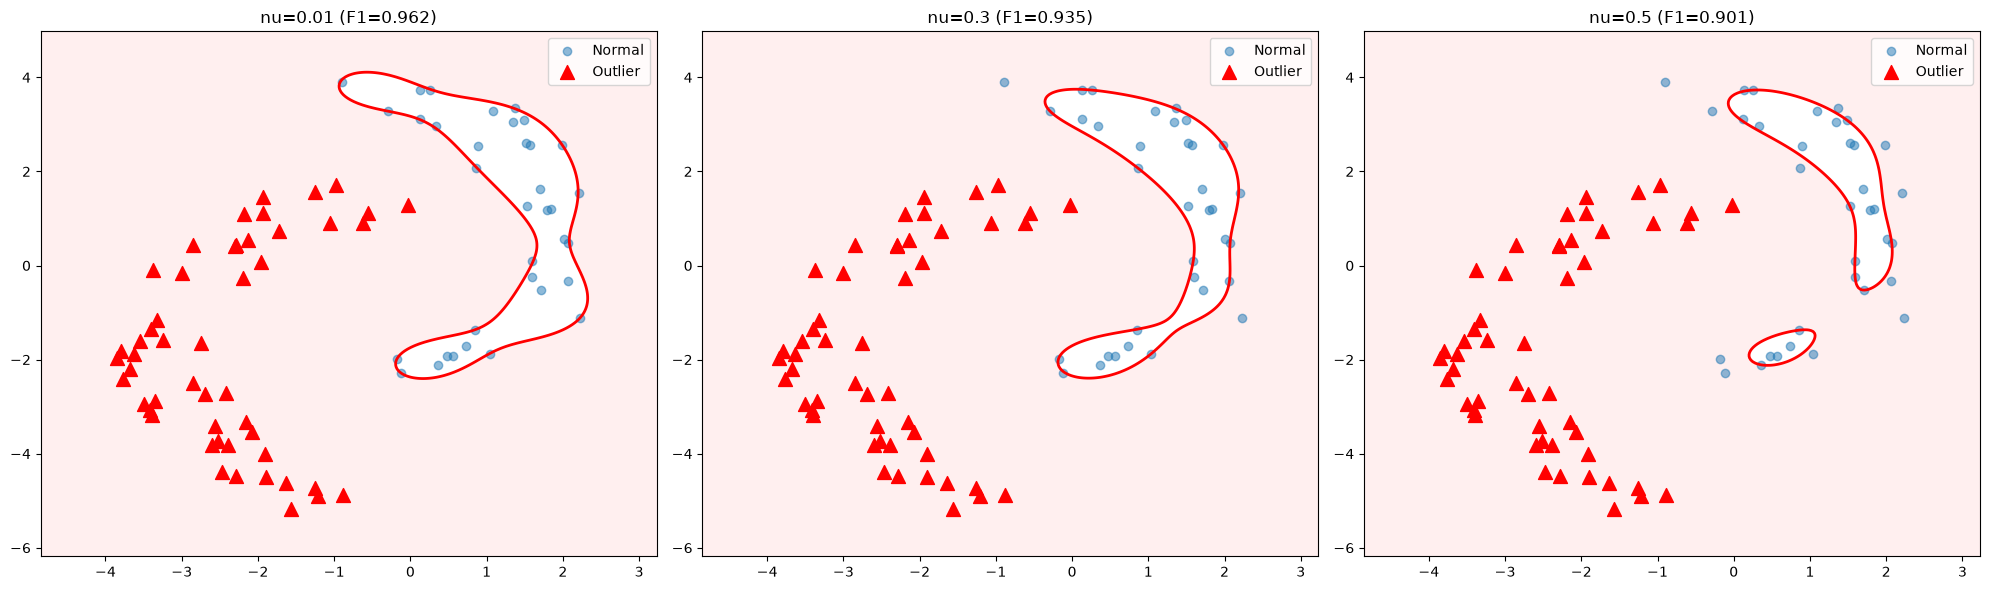

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
nu_values = [0.01, 0.3, 0.5]  

grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=["0", "1"]) 

for ax, nu in zip(axes, nu_values):
    model = OneClassSVM(kernel="rbf", gamma="auto", nu=nu)
    model.fit(X_train)

    Z = model.decision_function(grid_points).reshape(xx.shape) 

    ax.contourf(xx, yy, Z, levels=[Z.min(), 0], colors=["#ffcccc"], alpha=0.3)
    ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors="red")
    ax.scatter(X_train["0"], X_train["1"], label="Normal", alpha=0.5)
    ax.scatter(X_outlier["0"], X_outlier["1"], label="Outlier", marker="^", s=100, c="red")

    pred = model.predict(X_test)
    f1 = f1_score(Y_test, pred, pos_label=-1)
    ax.set_title(f"nu={nu} (F1={f1:.3f})")
    ax.legend()

plt.tight_layout()
plt.show()

In [10]:
# nu 값에 따른 성능 변화
results = []
for nu in [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]:
    model = OneClassSVM(kernel="rbf", gamma="auto", nu=nu)
    model.fit(X_train)
    pred = model.predict(X_test)
    results.append({
        "nu": nu,
        "F1-score": round(f1_score(Y_test, pred, pos_label=-1), 3),
        "Recall": round(recall_score(Y_test, pred, pos_label=-1), 3),
        "Precision": round(precision_score(Y_test, pred, pos_label=-1), 3)
    })

pd.DataFrame(results)

,nu,F1-score,Recall,Precision
0,0.01,0.962,1.0,0.926
1,0.05,0.962,1.0,0.926
2,0.10,0.962,1.0,0.926
3,0.15,0.962,1.0,0.926
4,0.20,0.962,1.0,0.926
5,0.30,0.935,1.0,0.877
6,0.50,0.901,1.0,0.820


---

## 4) Vibe Coding 실습

**[과제 1]** 지수는 nu 값에 따른 Boundary 변화는 확인했지만, gamma 파라미터도 Boundary 모양에 큰 영향을 준다는 것을 알게 되었습니다. gamma를 "auto"가 아니라 직접 여러 값으로 바꿔보면 어떤 차이가 나는지 궁금합니다. AI와 상의하여 gamma 값을 [0.01, 0.1, 1, 10]으로 바꿔가며 Boundary를 시각화하고 nu와 gamma가 각각 어떤 역할을 하는지 정리해 보세요.

In [ ]:
from IPython.display import Markdown, display

# gamma 값에 따른 Boundary 시각화 (nu는 고정)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
gamma_values = [0.01, 0.1, 1, 10]
nu_fixed = 0.1

grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=["0", "1"])

for ax, gamma in zip(axes.ravel(), gamma_values):
    model = OneClassSVM(kernel="rbf", gamma=gamma, nu=nu_fixed)
    model.fit(X_train)

    Z = model.decision_function(grid_points).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[Z.min(), 0], colors=["#ffcccc"], alpha=0.3)
    ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors="red")
    ax.scatter(X_train["0"], X_train["1"], label="Train (Normal)", alpha=0.5)
    ax.scatter(X_outlier["0"], X_outlier["1"], label="Outlier", marker="^", s=100, c="red")

    pred = model.predict(X_test)
    f1 = f1_score(Y_test, pred, pos_label=-1)
    ax.set_title(f"gamma={gamma}, nu={nu_fixed} (F1={f1:.3f})")
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")
    ax.legend()

plt.suptitle("gamma 변화에 따른 SVDD Boundary (nu=0.1 고정)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

display(Markdown("""
### `nu`와 `gamma` 파라미터 역할 정리

| 파라미터 | 역할 | 값이 작을 때 | 값이 클 때 |
|:---:|:---|:---|:---|
| **`nu`** | 학습 데이터 중 **이상치로 허용할 비율의 상한** (경계의 **크기/여유**) | Boundary가 **넓어짐** → 정상을 넓게 포함, 이상치 탐지가 어려움 (**과소적합**) | Boundary가 **좁아짐** → 정상도 이상치로 분류되기 쉬움 (**과적합**) |
| **`gamma`** | RBF 커널의 **영향 반경** (경계의 **곡률/복잡도**) | 영향 범위가 넓어 **부드럽고 단순한** 경계 (거의 원에 가까움) | 영향 범위가 좁아 **데이터 주변을 촘촘히 감싸는** 복잡한 경계 |

#### 핵심 차이
- **`nu`**: "경계를 **얼마나 크게/작게** 그릴 것인가" → 경계의 **전체적인 크기**
- **`gamma`**: "경계를 **얼마나 구불구불하게** 그릴 것인가" → 경계의 **모양(복잡도)**

#### 이번 시각화에서 관찰할 점
- **gamma=0.01**: 데이터 전체를 감싸는 **넓고 매끄러운** 경계
- **gamma=0.1**: 약간의 곡선이 생기지만 비교적 **단순한** 형태
- **gamma=1**: 데이터 분포에 맞춰 **굴곡이 뚜렷한** 경계
- **gamma=10**: 각 정상 데이터 포인트 주변에 **작은 섬처럼** 경계가 형성되어 **과적합**에 가까움

> 실무에서는 `nu`로 이상치 허용 비율을 조절하고, `gamma`로 경계의 유연성을 조절하며 두 파라미터를 함께 튜닝합니다.
"""))